# 03. Анализ ошибок и интерпретация

Детальный анализ предсказаний лучшей модели.

**Содержание:**
- Residual analysis
- Error distribution
- Comparison with subjective anxiety
- Outlier detection

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import joblib
import warnings
warnings.filterwarnings('ignore')

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
EXTRA_PATH = '/content/drive/MyDrive/'

In [11]:
df = pd.read_csv(EXTRA_PATH+'data/processed_data.csv')
model = joblib.load(EXTRA_PATH+'models/best_model.pkl')

TARGET = 'Anxiety_Level'
FEATURES = [c for c in df.columns if c not in [TARGET, 'Subjective_Anxiety']]

X = df[FEATURES]
y = df[TARGET]
y_subj = df['Subjective_Anxiety']

X_train, X_test, y_train, y_test, y_subj_train, y_subj_test = train_test_split(
    X, y, y_subj, test_size=0.2, random_state=42
)

y_pred = model.predict(X_test)

## Residual Analysis

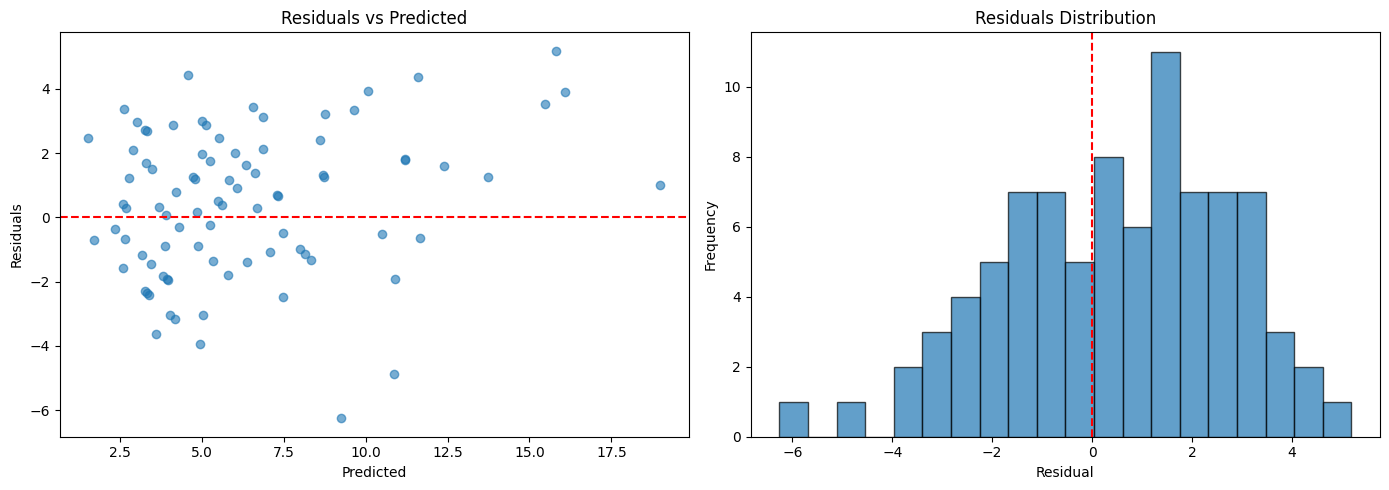

Mean residual: 0.447
Std residual: 2.265


In [12]:
residuals = y_test.values - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred, residuals, alpha=0.6)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted')

axes[1].hist(residuals, bins=20, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residuals Distribution')

plt.tight_layout()
plt.show()

print(f"Mean residual: {np.mean(residuals):.3f}")
print(f"Std residual: {np.std(residuals):.3f}")

## Error Distribution

### QQ plot of error distribution

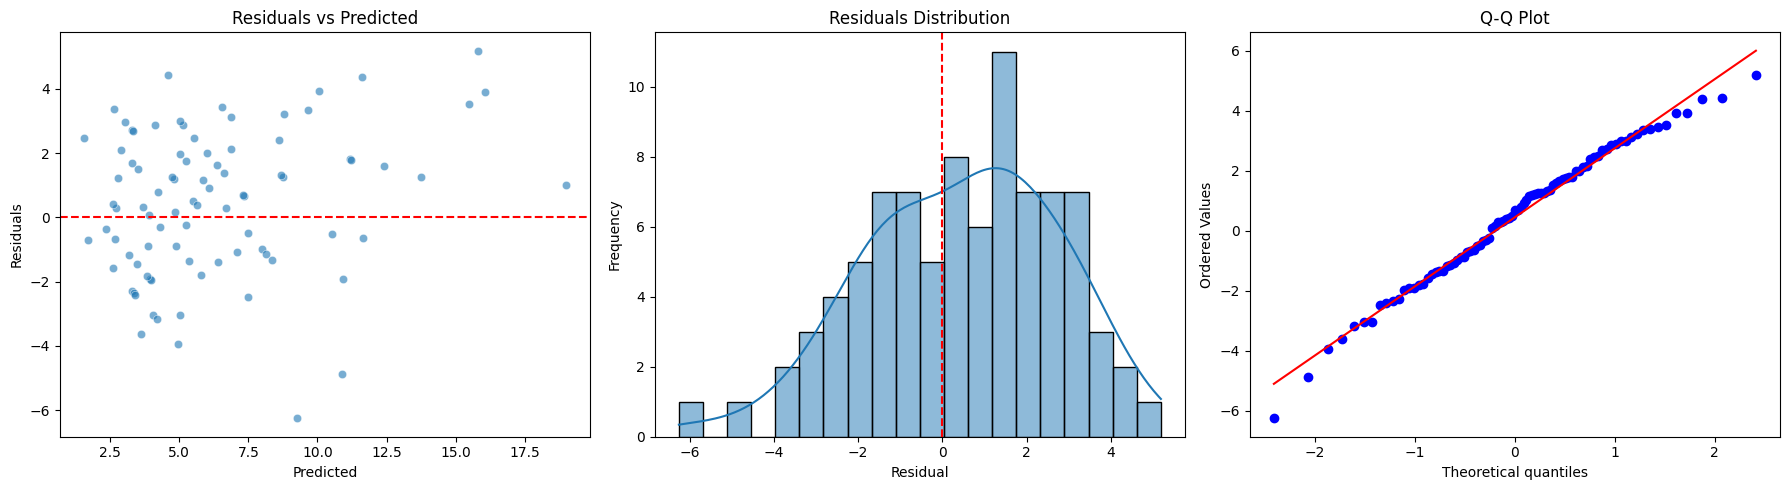

Mean residual:  0.447
Std residual:   2.265
Skewness:       -0.340
Kurtosis:       -0.183


In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np

residuals = y_test.values - y_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Residuals vs Predicted
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6, ax=axes[0])
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted')

# 2. Residuals Distribution (histplot + kde)
sns.histplot(residuals, bins=20, kde=True, ax=axes[1])
axes[1].axvline(x=0, color='red', linestyle='--')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residuals Distribution')

# 3. Q-Q plot
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot')

plt.tight_layout()
plt.show()

print(f"Mean residual:  {np.mean(residuals):.3f}")
print(f"Std residual:   {np.std(residuals):.3f}")
print(f"Skewness:       {stats.skew(residuals):.3f}")
print(f"Kurtosis:       {stats.kurtosis(residuals):.3f}")

## Comparison: GAD-7 vs Subjective Anxiety

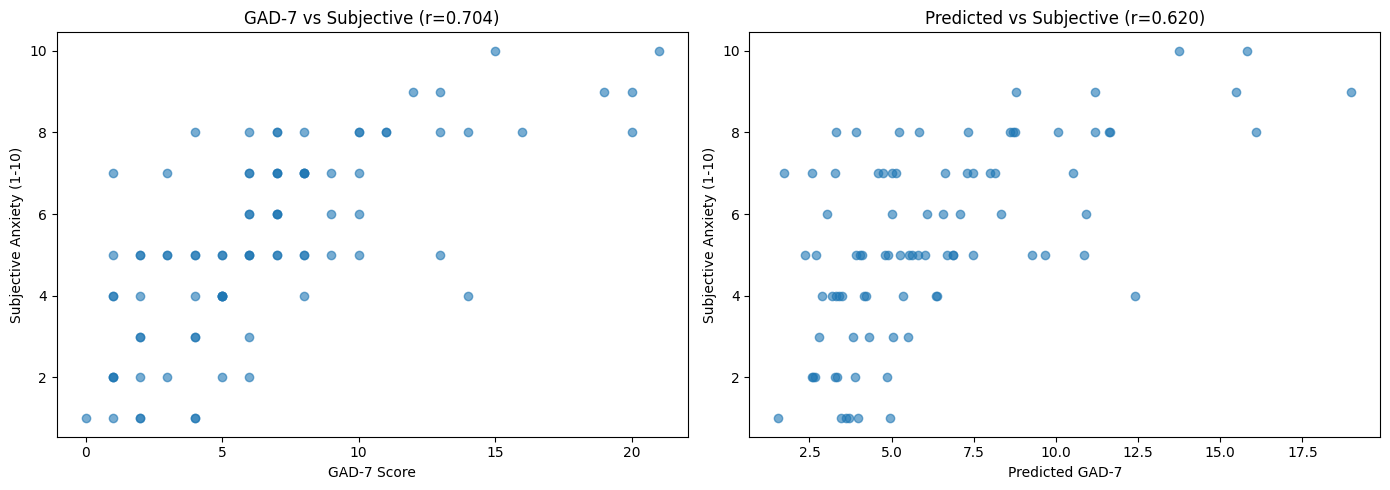

Корреляция между объективной и субъективной оценкой:
  GAD-7 ↔ Subj: r=0.704
  Predicted ↔ Subj: r=0.620


In [14]:
from scipy.stats import pearsonr

corr_gad_subj, p_val = pearsonr(y_test, y_subj_test)
corr_pred_subj, _ = pearsonr(y_pred, y_subj_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_subj_test, alpha=0.6)
axes[0].set_xlabel('GAD-7 Score')
axes[0].set_ylabel('Subjective Anxiety (1-10)')
axes[0].set_title(f'GAD-7 vs Subjective (r={corr_gad_subj:.3f})')

axes[1].scatter(y_pred, y_subj_test, alpha=0.6)
axes[1].set_xlabel('Predicted GAD-7')
axes[1].set_ylabel('Subjective Anxiety (1-10)')
axes[1].set_title(f'Predicted vs Subjective (r={corr_pred_subj:.3f})')

plt.tight_layout()
plt.show()

print("Корреляция между объективной и субъективной оценкой:")
print(f"  GAD-7 ↔ Subj: r={corr_gad_subj:.3f}")
print(f"  Predicted ↔ Subj: r={corr_pred_subj:.3f}")

## Outlier Analysis

In [15]:
error_threshold = np.mean(errors) + 2 * np.std(errors)
outliers = errors > error_threshold

outlier_df = pd.DataFrame({
    'Actual': y_test.values[outliers],
    'Predicted': y_pred[outliers],
    'Error': errors[outliers]
})

print(f"Выбросы (ошибка > {error_threshold:.2f}): {len(outlier_df)}")
print(f"\n{outlier_df.to_string(index=False)}")

Выбросы (ошибка > 4.48): 3

 Actual  Predicted    Error
      3   9.258042 6.258042
     21  15.809863 5.190137
      6  10.869902 4.869902


## Error by Feature Range

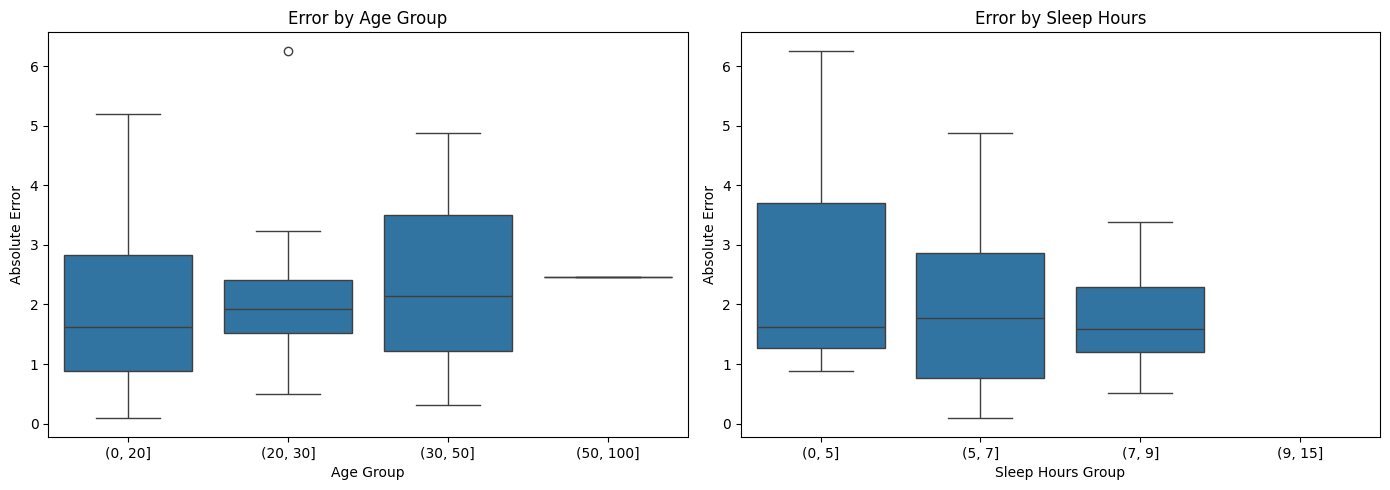

In [16]:
X_test_reset = X_test.reset_index(drop=True)
error_df = pd.DataFrame({
    'Error': errors,
    'Age': X_test_reset['Age'],
    'Sleep_Hours': X_test_reset['Sleep_Hours']
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=error_df, x=pd.cut(error_df['Age'], bins=[0, 20, 30, 50, 100]), y='Error', ax=axes[0])
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Absolute Error')
axes[0].set_title('Error by Age Group')

sns.boxplot(data=error_df, x=pd.cut(error_df['Sleep_Hours'], bins=[0, 5, 7, 9, 15]), y='Error', ax=axes[1])
axes[1].set_xlabel('Sleep Hours Group')
axes[1].set_ylabel('Absolute Error')
axes[1].set_title('Error by Sleep Hours')

plt.tight_layout()
plt.show()

## Summary

In [17]:
print("="*50)
print("ИТОГОВЫЙ ОТЧЁТ")
print("="*50)
print(f"\nКачество модели:")
print(f"  MAE: {np.mean(errors):.3f}")
print(f"  RMSE: {np.sqrt(np.mean(errors**2)):.3f}")

print(f"\nВыбросов: {outliers.sum()} ({100*outliers.sum()/len(errors):.1f}%)")

print(f"\nКорреляции:")
print(f"  GAD-7 ↔ Subj: {corr_gad_subj:.3f}")
print(f"  Predicted ↔ Subj: {corr_pred_subj:.3f}")

print("\n" + "="*50)

ИТОГОВЫЙ ОТЧЁТ

Качество модели:
  MAE: 1.921
  RMSE: 2.309

Выбросов: 3 (3.4%)

Корреляции:
  GAD-7 ↔ Subj: 0.704
  Predicted ↔ Subj: 0.620

